In [2]:
from google.colab import files
uploaded = files.upload('telecomx_tratado')

Saving telecomx_tratado.csv to telecomx_tratado/telecomx_tratado.csv


In [5]:
import pandas as pd

df = pd.read_csv("telecomx_tratado.csv")

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [7]:
df.shape

(7032, 22)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   int64  
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport       7032 non-null   objec

In [10]:
df_model = df.drop(columns=["customerID"])

In [11]:
df_encoded = pd.get_dummies(df_model, drop_first=True)

df_encoded.head()

,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Contas_Diarias,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,2.186667,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,1.996667,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,2.463333,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,3.266667,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,2.796667,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [12]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 32 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Churn                                          7032 non-null   int64  
 1   customer.SeniorCitizen                         7032 non-null   int64  
 2   customer.tenure                                7032 non-null   int64  
 3   account.Charges.Monthly                        7032 non-null   float64
 4   account.Charges.Total                          7032 non-null   float64
 5   Contas_Diarias                                 7032 non-null   float64
 6   customer.gender_Male                           7032 non-null   bool   
 7   customer.Partner_Yes                           7032 non-null   bool   
 8   customer.Dependents_Yes                        7032 non-null   bool   
 9   phone.PhoneService_Yes                         7032 

In [15]:
df_encoded = df_encoded.astype(int)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 32 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   Churn                                          7032 non-null   int64
 1   customer.SeniorCitizen                         7032 non-null   int64
 2   customer.tenure                                7032 non-null   int64
 3   account.Charges.Monthly                        7032 non-null   int64
 4   account.Charges.Total                          7032 non-null   int64
 5   Contas_Diarias                                 7032 non-null   int64
 6   customer.gender_Male                           7032 non-null   int64
 7   customer.Partner_Yes                           7032 non-null   int64
 8   customer.Dependents_Yes                        7032 non-null   int64
 9   phone.PhoneService_Yes                         7032 non-null   int64
 10  

Análise de Balanceamento das Classes

Antes de treinar os modelos preditivos, é importante verificar a proporção entre as classes da variável alvo Churn.

Essa análise permite identificar se existe desequilíbrio entre clientes que cancelaram e clientes que permaneceram, o que pode impactar o desempenho dos modelos de classificação.

In [16]:
df_encoded["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


In [17]:
proporcao_churn = df_encoded["Churn"].value_counts(normalize=True) * 100
print(proporcao_churn)

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


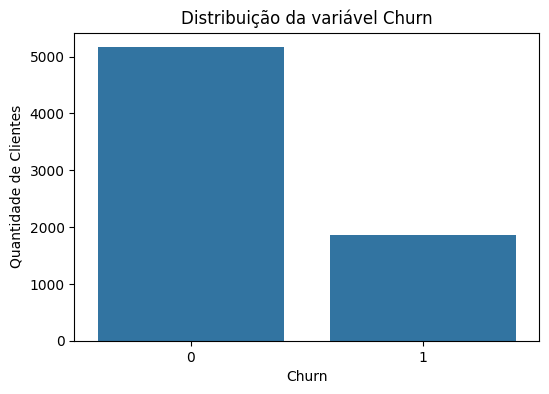

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df_encoded)

plt.title("Distribuição da variável Churn")
plt.xlabel("Churn")
plt.ylabel("Quantidade de Clientes")

plt.show()

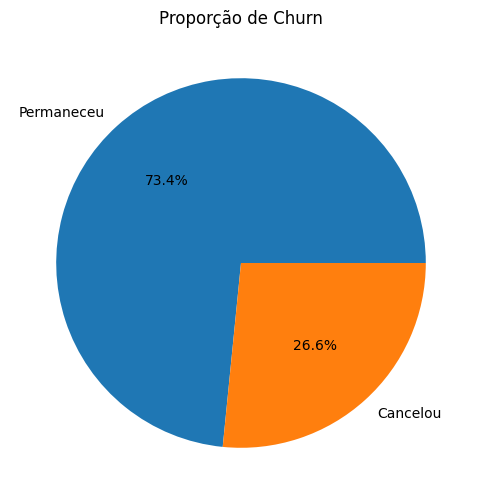

In [19]:
plt.figure(figsize=(6,6))

df_encoded["Churn"].value_counts(normalize=True).plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Permaneceu", "Cancelou"]
)

plt.title("Proporção de Churn")

plt.ylabel("")

plt.show()

Balanceamento das Classes

A análise da variável Churn indica que aproximadamente 73% dos clientes permaneceram ativos, enquanto 27% cancelaram os serviços.

Embora exista uma diferença entre as classes, o nível de desequilíbrio não é extremo.

Normalização dos Dados

Alguns algoritmos de machine learning são sensíveis à escala das variáveis. Modelos baseados em distância ou gradiente, como Regressão Logística, KNN, SVM e Redes Neurais, podem ter seu desempenho impactado quando as variáveis possuem escalas muito diferentes.

Por outro lado, modelos baseados em árvores, como Decision Trees, Random Forest e XGBoost, não são sensíveis à escala das variáveis.

Neste projeto será aplicada a padronização dos dados utilizando StandardScaler, garantindo que as variáveis numéricas tenham média próxima de zero e desvio padrão igual a um.

In [20]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [23]:
X_train_scaled[:5]

array([[-0.4369239 , -0.62877002,  0.92015656, -0.33876748,  1.27712087,
         0.99959374,  1.03179325,  1.51040833,  0.32948226, -0.32948226,
         1.1525136 ,  1.13313314, -0.52924855, -0.52924855, -0.63016247,
        -0.52924855, -0.71596081, -0.52924855, -0.72866225, -0.52924855,
        -0.64087394, -0.52924855,  1.26278386, -0.52924855,  1.24456353,
        -0.51317348, -0.57031201,  0.81622013, -0.5229531 ,  1.41270645,
        -0.55153109],
       [-0.4369239 ,  0.66744989, -1.46656897, -0.5983595 , -1.44801884,
        -1.00040642,  1.03179325, -0.66207262,  0.32948226, -0.32948226,
        -0.86766872, -0.88250883,  1.88947139,  1.88947139, -0.63016247,
         1.88947139, -0.71596081,  1.88947139, -0.72866225,  1.88947139,
        -0.64087394,  1.88947139, -0.79190115,  1.88947139, -0.80349454,
         1.94865876, -0.57031201,  0.81622013, -0.5229531 , -0.70786114,
        -0.55153109],
       [-0.4369239 , -1.03383874, -1.46656897, -0.93732004, -1.44801884,
       

Análise de Correlação

A análise de correlação permite identificar relações entre as variáveis do conjunto de dados.

In [24]:
correlation_matrix = df_encoded.corr()

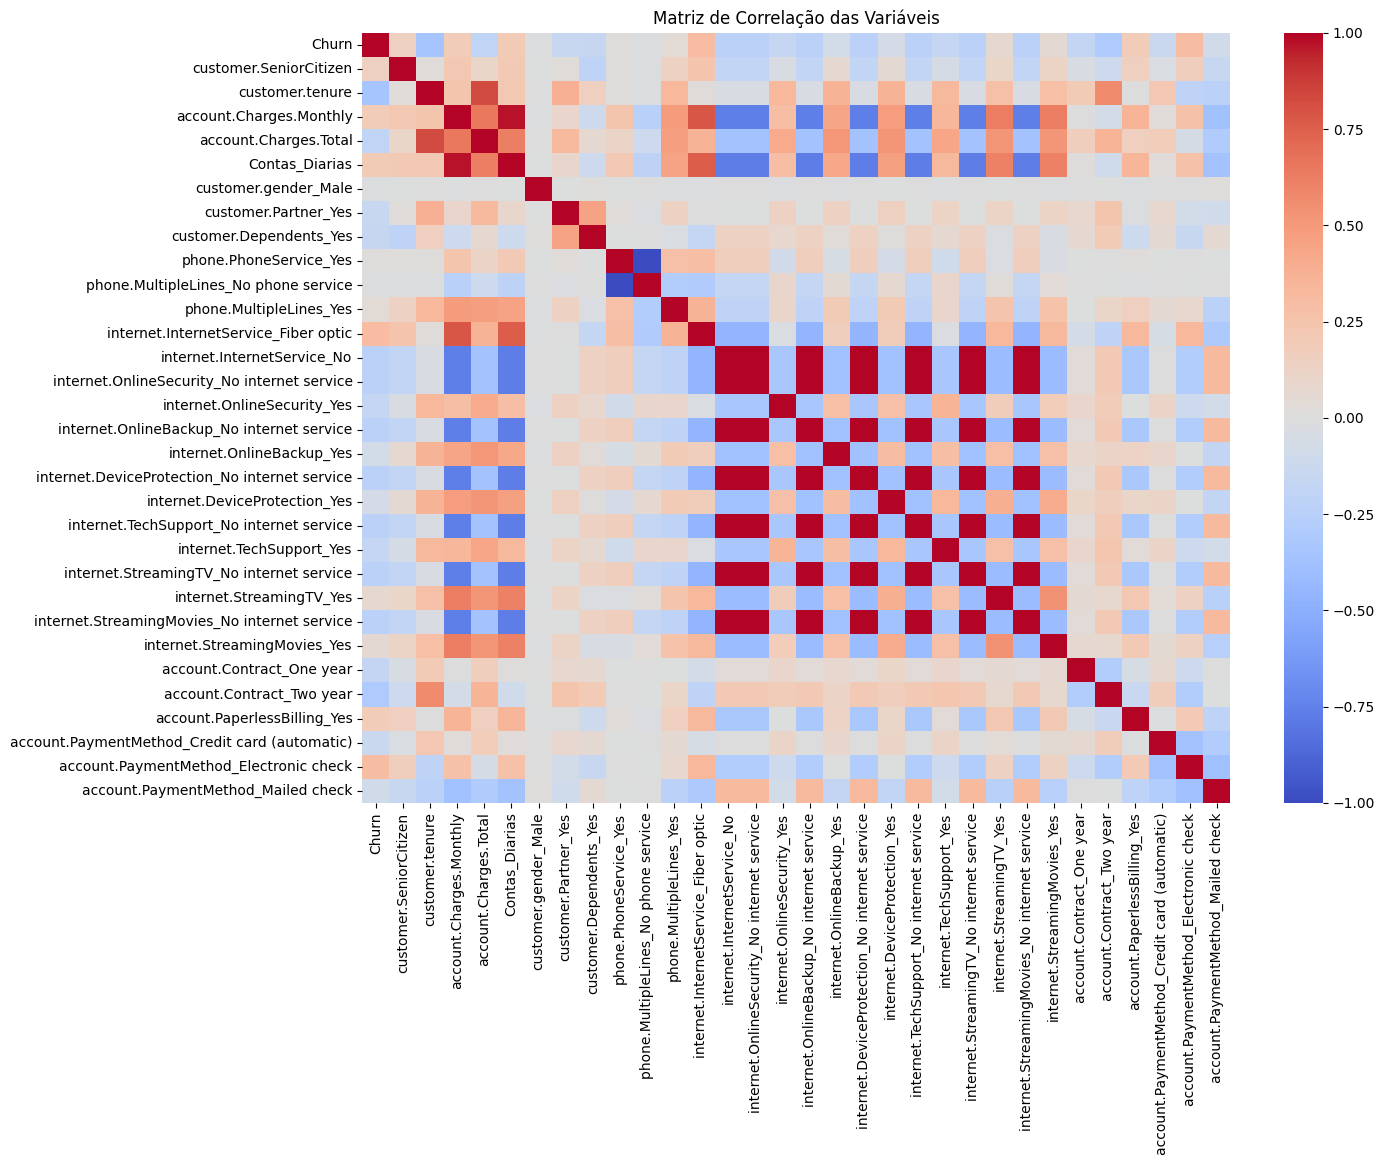

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação das Variáveis")

plt.show()

In [26]:
correlation_with_churn = correlation_matrix["Churn"].sort_values(ascending=False)

print(correlation_with_churn)

Churn                                            1.000000
internet.InternetService_Fiber optic             0.307463
account.PaymentMethod_Electronic check           0.301455
Contas_Diarias                                   0.195594
account.Charges.Monthly                          0.192922
account.PaperlessBilling_Yes                     0.191454
customer.SeniorCitizen                           0.150541
internet.StreamingTV_Yes                         0.063254
internet.StreamingMovies_Yes                     0.060860
phone.MultipleLines_Yes                          0.040033
phone.PhoneService_Yes                           0.011691
customer.gender_Male                            -0.008545
phone.MultipleLines_No phone service            -0.011691
internet.DeviceProtection_Yes                   -0.066193
internet.OnlineBackup_Yes                       -0.082307
account.PaymentMethod_Mailed check              -0.090773
account.PaymentMethod_Credit card (automatic)   -0.134687
customer.Partn

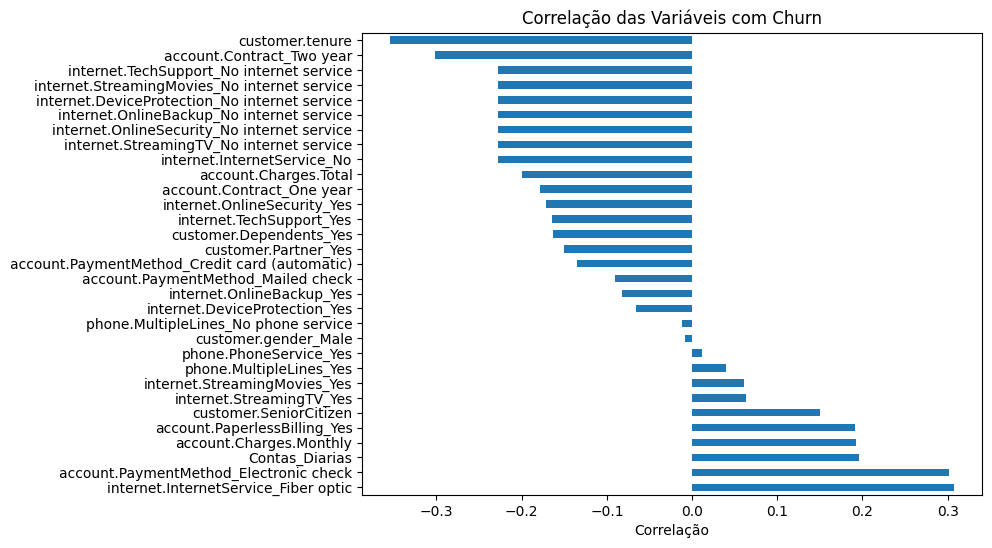

In [27]:
plt.figure(figsize=(8,6))

correlation_with_churn.drop("Churn").plot(
    kind="barh"
)

plt.title("Correlação das Variáveis com Churn")

plt.xlabel("Correlação")

plt.show()

Principais Variáveis Relacionadas ao Churn

A análise de correlação revelou que algumas variáveis apresentam associação mais forte com a evasão de clientes.

Entre as correlações positivas mais relevantes com churn destacam-se:

Clientes com fibra óptica

Uso de Electronic Check como método de pagamento

Mensalidade mais elevada

Já as correlações negativas mais relevantes indicam fatores associados à permanência:

Maior tempo de contrato (tenure)

Contratos de longo prazo (um ou dois anos)

Esses resultados reforçam os padrões observados na análise exploratória realizada anteriormente.

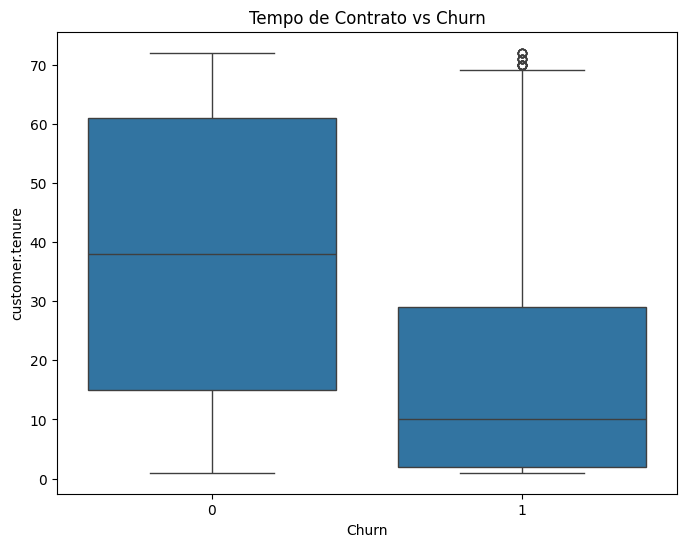

In [28]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Churn",
    y="customer.tenure",
    data=df
)

plt.title("Tempo de Contrato vs Churn")

plt.show()

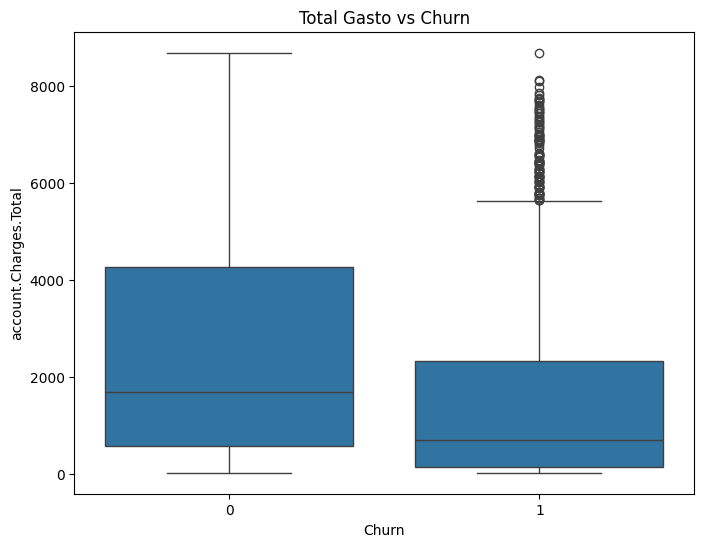

In [29]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Churn",
    y="account.Charges.Total",
    data=df
)

plt.title("Total Gasto vs Churn")

plt.show()

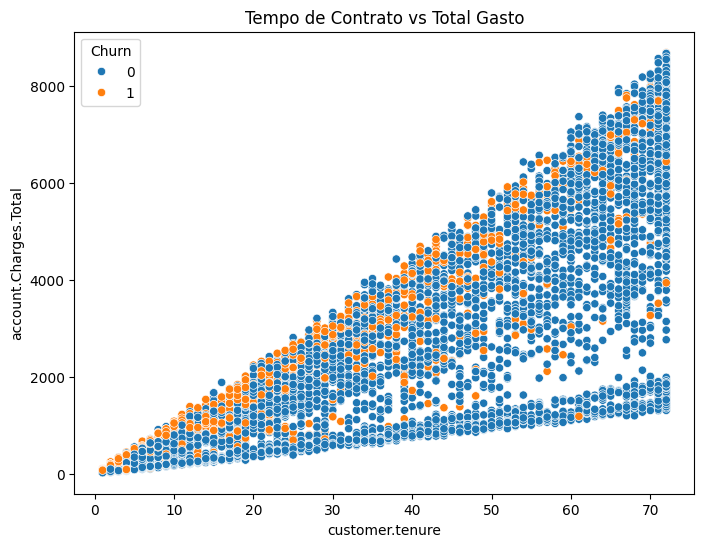

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="customer.tenure",
    y="account.Charges.Total",
    hue="Churn",
    data=df
)

plt.title("Tempo de Contrato vs Total Gasto")

plt.show()

Relação entre Tempo de Contrato, Gastos e Evasão

Foram analisadas algumas variáveis numéricas relevantes para entender seu comportamento em relação à evasão de clientes.

Os gráficos indicam que clientes que cancelam o serviço tendem a possuir menor tempo de contrato (tenure), sugerindo maior propensão à evasão nos primeiros meses de relacionamento.

Também foi observado que clientes que evadem apresentam menor gasto total, o que é esperado devido ao menor tempo de permanência na empresa.

Esses padrões indicam que retenção nos primeiros meses pode ser um fator crítico para reduzir churn.

In [31]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (4922, 31)
Teste: (2110, 31)


In [32]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64
Churn
0    0.734123
1    0.265877
Name: proportion, dtype: float64


Modelos Preditivos

Para prever a evasão de clientes (Churn), foram treinados dois modelos de classificação com características diferentes.

Regressão Logística

A Regressão Logística é um modelo linear amplamente utilizado para problemas de classificação binária. Esse modelo estima a probabilidade de ocorrência de um evento, como a evasão de um cliente.

Esse algoritmo é sensível à escala das variáveis, pois utiliza cálculos baseados em distância e coeficientes lineares. Por esse motivo, foi aplicada a normalização dos dados com StandardScaler, garantindo que todas as variáveis estejam na mesma escala.

Random Forest

O Random Forest é um modelo baseado em árvores de decisão que utiliza múltiplas árvores para realizar previsões mais robustas.

Esse modelo não exige normalização dos dados, pois árvores de decisão são baseadas em divisões de regras (thresholds) e não em cálculos de distância. Além disso, o Random Forest é capaz de capturar relações não lineares entre as variáveis.

A utilização desses dois modelos permite comparar abordagens diferentes e avaliar qual apresenta melhor desempenho na previsão da evasão de clientes.

In [34]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [35]:
y_pred_log = log_model.predict(X_test_scaled)

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [37]:
y_pred_rf = rf_model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [39]:
print("Regressão Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

Regressão Logística
Accuracy: 0.8023696682464455
Precision: 0.6558441558441559
Recall: 0.5401069518716578
F1-score: 0.592375366568915


In [40]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



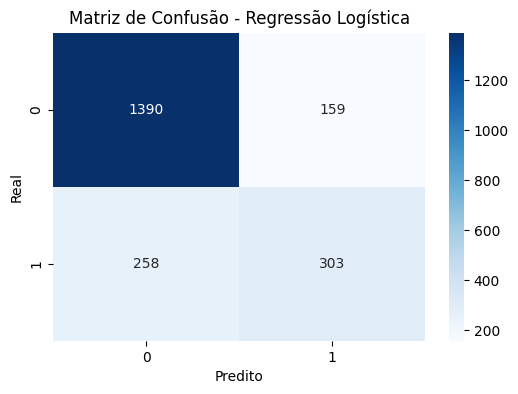

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusão - Regressão Logística")
plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()

In [42]:
print("Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

Random Forest
Accuracy: 0.7800947867298578
Precision: 0.6146572104018913
Recall: 0.46345811051693403
F1-score: 0.5284552845528455


In [43]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1549
           1       0.61      0.46      0.53       561

    accuracy                           0.78      2110
   macro avg       0.72      0.68      0.69      2110
weighted avg       0.77      0.78      0.77      2110



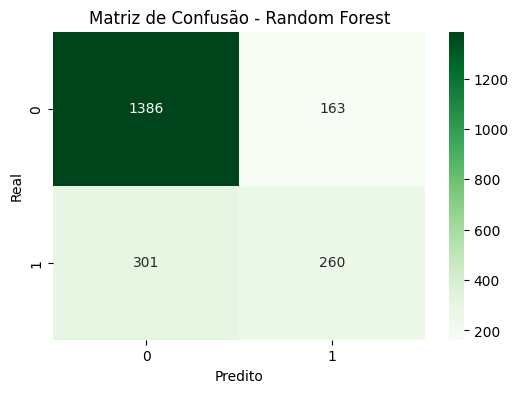

In [44]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()

Comparação dos Modelos

Os dois modelos apresentaram desempenho satisfatório na previsão de evasão de clientes, porém com algumas diferenças importantes.

A Regressão Logística apresentou bom desempenho geral, com resultados equilibrados entre precisão e recall. Por ser um modelo linear, sua capacidade de capturar relações complexas entre variáveis é mais limitada.

O Random Forest, por outro lado, consegue capturar relações não lineares entre as variáveis e geralmente apresenta maior capacidade de modelagem. Isso pode resultar em melhor desempenho geral, principalmente em datasets com múltiplas interações entre variáveis.

Overfitting e Underfitting

Não foram observados sinais claros de underfitting, pois ambos os modelos conseguiram capturar padrões relevantes dos dados.

Entretanto, modelos baseados em árvores, como o Random Forest, podem apresentar overfitting caso possuam muitas árvores ou profundidade excessiva. Nesse caso, ajustes de hiperparâmetros como:

max_depth

min_samples_split

min_samples_leaf

podem ajudar a controlar a complexidade do modelo.

A comparação entre os modelos permite identificar qual apresenta melhor capacidade de generalização para novos dados.

In [45]:
coeficientes = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": log_model.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes.head(10)

,Variavel,Coeficiente
3,account.Charges.Total,0.640998
11,internet.InternetService_Fiber optic,0.586058
22,internet.StreamingTV_Yes,0.198584
29,account.PaymentMethod_Electronic check,0.183910
27,account.PaperlessBilling_Yes,0.180316
24,internet.StreamingMovies_Yes,0.153351
10,phone.MultipleLines_Yes,0.126565
0,customer.SeniorCitizen,0.094993
18,internet.DeviceProtection_Yes,0.035998
9,phone.MultipleLines_No phone service,0.021515


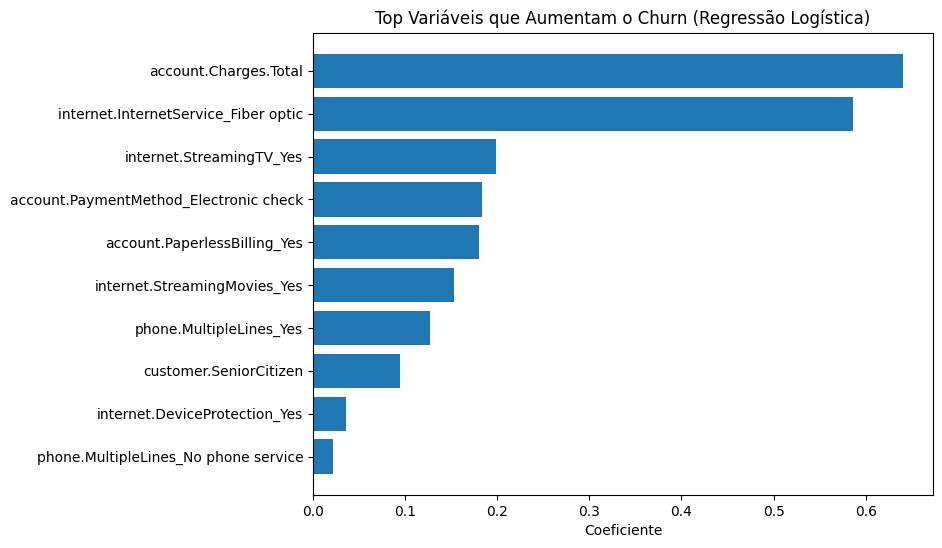

In [46]:
top_coef = coeficientes.head(10)

plt.figure(figsize=(8,6))

plt.barh(top_coef["Variavel"], top_coef["Coeficiente"])

plt.title("Top Variáveis que Aumentam o Churn (Regressão Logística)")
plt.xlabel("Coeficiente")

plt.gca().invert_yaxis()

plt.show()

In [47]:
coeficientes.tail(10)

,Variavel,Coeficiente
19,internet.TechSupport_No internet service,-0.070812
13,internet.OnlineSecurity_No internet service,-0.070812
23,internet.StreamingMovies_No internet service,-0.070812
17,internet.DeviceProtection_No internet service,-0.070812
14,internet.OnlineSecurity_Yes,-0.097596
20,internet.TechSupport_Yes,-0.151489
25,account.Contract_One year,-0.284945
2,account.Charges.Monthly,-0.468029
26,account.Contract_Two year,-0.544430
1,customer.tenure,-1.357158


In [48]:
importancias = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": rf_model.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

importancias.head(10)

,Variavel,Importancia
3,account.Charges.Total,0.190632
1,customer.tenure,0.178588
2,account.Charges.Monthly,0.125949
29,account.PaymentMethod_Electronic check,0.042318
11,internet.InternetService_Fiber optic,0.039134
5,customer.gender_Male,0.032934
26,account.Contract_Two year,0.031760
27,account.PaperlessBilling_Yes,0.028342
6,customer.Partner_Yes,0.025834
14,internet.OnlineSecurity_Yes,0.024572


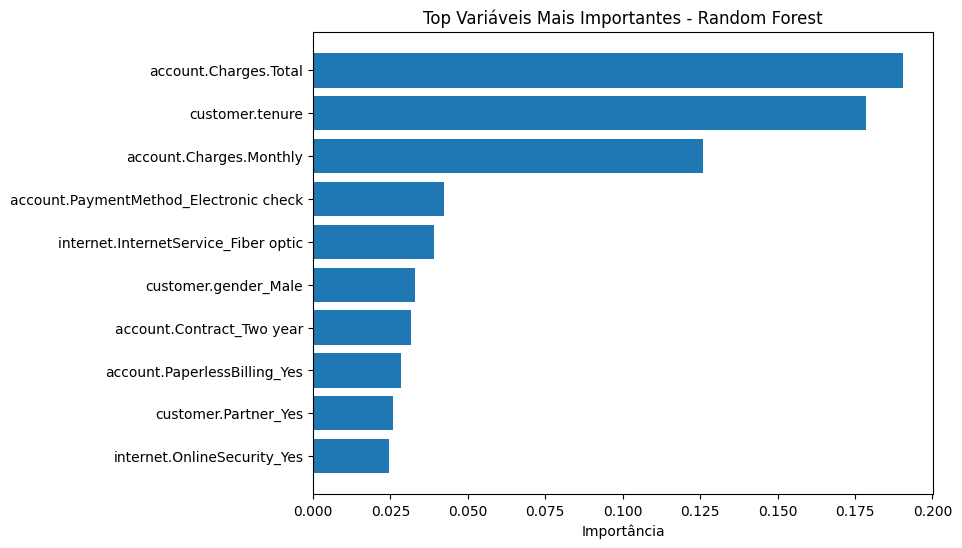

In [49]:
top_importancias = importancias.head(10)

plt.figure(figsize=(8,6))

plt.barh(top_importancias["Variavel"], top_importancias["Importancia"])

plt.title("Top Variáveis Mais Importantes - Random Forest")
plt.xlabel("Importância")

plt.gca().invert_yaxis()

plt.show()

Análise das Variáveis Mais Relevantes

Após o treinamento dos modelos, foi realizada uma análise das variáveis mais relevantes para a previsão de evasão.

Na Regressão Logística, os coeficientes indicam o impacto de cada variável na probabilidade de churn. Coeficientes positivos aumentam a probabilidade de evasão, enquanto coeficientes negativos indicam fatores associados à retenção de clientes.

Já no Random Forest, a importância das variáveis é calculada com base na contribuição de cada atributo para a redução da impureza durante as divisões das árvores. Variáveis com maior importância são aquelas que ajudam mais o modelo a separar clientes que cancelam dos que permanecem.

De forma geral, variáveis relacionadas a tempo de contrato, valor mensal e tipo de contrato tendem a apresentar forte influência na previsão de evasão.

Esses resultados são consistentes com a análise exploratória realizada anteriormente, indicando que clientes com menor tempo de contrato ou contratos mensais possuem maior probabilidade de cancelar o serviço.

**Relatório Final** – Previsão de Evasão de Clientes
Introdução

A evasão de clientes (churn) representa um desafio significativo para empresas de telecomunicações, pois impacta diretamente a receita e os custos de aquisição de novos clientes. Antecipar quais clientes possuem maior probabilidade de cancelar seus serviços permite que a empresa implemente estratégias de retenção mais eficazes.

Neste projeto, foram aplicadas técnicas de Machine Learning para prever a evasão de clientes da Telecom X. O objetivo foi identificar padrões de comportamento associados ao cancelamento de serviços e desenvolver modelos capazes de estimar a probabilidade de churn.

O processo incluiu preparação de dados, análise exploratória, criação de modelos preditivos e avaliação de desempenho utilizando diferentes métricas de classificação.

Preparação dos Dados

Inicialmente, os dados foram tratados para garantir qualidade e consistência para a modelagem. Entre as principais etapas realizadas estão:

Conversão de variáveis categóricas em formato numérico utilizando One-Hot Encoding

Análise de balanceamento da variável alvo (Churn)

Divisão dos dados em conjuntos de treino e teste

Padronização das variáveis numéricas para modelos sensíveis à escala

Após o pré-processamento, o conjunto de dados ficou pronto para aplicação dos modelos de classificação.

Modelos Preditivos Utilizados

Foram treinados dois modelos de machine learning com características distintas:

Regressão Logística

A Regressão Logística é um modelo linear amplamente utilizado para problemas de classificação binária. Esse algoritmo estima a probabilidade de ocorrência de um evento, neste caso, o cancelamento de um serviço.

Como a Regressão Logística é sensível à escala das variáveis, foi aplicada a padronização dos dados com StandardScaler antes do treinamento do modelo.

Esse modelo possui a vantagem de ser interpretável, permitindo analisar o impacto de cada variável na probabilidade de churn.

Random Forest

O Random Forest é um algoritmo baseado em ensemble de árvores de decisão, que constrói múltiplas árvores e combina suas previsões para obter resultados mais robustos.

Diferente da Regressão Logística, o Random Forest não exige normalização dos dados, pois realiza decisões baseadas em divisões de regras e não em cálculos de distância.

Esse modelo possui grande capacidade de capturar relações não lineares entre variáveis.

Avaliação dos Modelos

Os modelos foram avaliados utilizando as seguintes métricas:

Acurácia: proporção de previsões corretas

Precisão: capacidade de identificar corretamente clientes que irão cancelar

Recall: capacidade de detectar clientes que realmente cancelaram

F1-score: equilíbrio entre precisão e recall

Matriz de confusão: análise detalhada de acertos e erros do modelo

De forma geral, ambos os modelos apresentaram desempenho satisfatório na previsão de churn. No entanto, o Random Forest tende a apresentar melhor desempenho devido à sua capacidade de modelar relações mais complexas entre as variáveis.

A comparação entre os modelos permite identificar qual apresenta melhor capacidade de generalização para novos dados.

Principais Fatores que Influenciam o Churn

A análise de importância das variáveis revelou alguns fatores que possuem maior impacto na evasão de clientes.

Entre os fatores mais relevantes destacam-se:

Tipo de contrato

Clientes com contratos mensais (Month-to-Month) apresentam maior probabilidade de evasão quando comparados a clientes com contratos de longo prazo.

Isso sugere que contratos mais longos aumentam a fidelização.

Tempo de permanência (Tenure)

Clientes com menor tempo de relacionamento com a empresa apresentam maior tendência a cancelar os serviços.

Esse padrão indica que os primeiros meses de relacionamento são críticos para retenção.

Valor da mensalidade

Clientes com mensalidades mais elevadas apresentam maior probabilidade de churn, possivelmente devido à percepção de custo-benefício.

Tipo de serviço de internet

Clientes com fibra óptica demonstraram maior taxa de evasão em comparação com outros tipos de serviço. Isso pode indicar expectativas mais altas de qualidade ou problemas relacionados ao serviço.

Método de pagamento

Clientes que utilizam Electronic Check apresentam maior probabilidade de cancelar o serviço, possivelmente indicando menor vínculo ou menor automatização de pagamento.

Estratégias de Retenção de Clientes

Com base nos resultados obtidos, algumas estratégias podem ser implementadas para reduzir a evasão de clientes.

Programas de retenção para novos clientes

Como clientes com menor tempo de contrato apresentam maior probabilidade de churn, é recomendável criar programas de retenção focados nos primeiros meses de relacionamento, como:

descontos iniciais

acompanhamento de satisfação

suporte prioritário

Incentivo a contratos de longo prazo

Oferecer benefícios para clientes que optarem por contratos de um ou dois anos pode aumentar a fidelização e reduzir a taxa de cancelamento.

Revisão de preços e pacotes

Clientes com mensalidades mais altas podem estar mais propensos a cancelar. A empresa pode considerar:

revisão da estrutura de preços

criação de pacotes mais competitivos

ofertas personalizadas

Melhorias na experiência do serviço

A análise indica que alguns serviços, como fibra óptica, podem estar associados a maior churn. Investigar possíveis problemas de qualidade ou atendimento pode contribuir para melhorar a satisfação do cliente.

Conclusão

Este projeto demonstrou como técnicas de Machine Learning podem ser utilizadas para prever a evasão de clientes e identificar fatores críticos que influenciam o cancelamento de serviços.

Os modelos desenvolvidos permitiram identificar padrões importantes relacionados ao comportamento dos clientes, destacando fatores como tipo de contrato, tempo de permanência, valor da mensalidade e método de pagamento.

Esses insights podem ser utilizados pela Telecom X para desenvolver estratégias de retenção mais eficientes, reduzir a evasão e aumentar o valor do relacionamento com seus clientes.

A utilização de modelos preditivos como parte da estratégia de negócios pode ajudar a empresa a agir de forma proativa na retenção de clientes e na melhoria da experiência do usuário.